# Install & Import Libraries

In [2]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 251.5 kB/s eta 0:23:15
   ---------------------------------------- 0.5/351.2 MB 251.5 kB/s eta 0:23:15
   ---------------------------------------- 0.5/351.2 MB 25

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

 # Load & Prepare Data

In [4]:
# Load dataset
iris = load_iris()
X = iris.data        # 4 features: sepal length, sepal width, petal length, petal width
y = iris.target.reshape(-1, 1)  # 3 classes: setosa, versicolor, virginica

# One-hot encode the output (as the article explains)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Standardize input features (mean=0, std=1 — as article recommends)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


 # Build the Network

In [5]:
model = Sequential([
    Dense(8, input_dim=4, activation='relu'),   
    Dense(8, activation='relu'),                
    Dense(3, activation='softmax')              
])

model.summary()

E:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

# Train the Network

In [6]:
model.compile(
    optimizer='adam',           
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=100,                 
    batch_size=16,              
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.3333 - loss: 1.2681 - val_accuracy: 0.5000 - val_loss: 1.1706
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3426 - loss: 1.2294 - val_accuracy: 0.1667 - val_loss: 1.1531
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2685 - loss: 1.1904 - val_accuracy: 0.1667 - val_loss: 1.1367
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2593 - loss: 1.1550 - val_accuracy: 0.1667 - val_loss: 1.1190
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2593 - loss: 1.1168 - val_accuracy: 0.1667 - val_loss: 1.0983
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2593 - loss: 1.0821 - val_accuracy: 0.1667 - val_loss: 1.0771
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3148 - loss: 1.0431 - val_accuracy: 0.2500 - val_loss: 1.0559
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4444 - loss: 1.0069 - val_accuracy: 0.2500 - val_loss:

# Evaluate & Predict

In [7]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Make a prediction on one sample
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)
predicted_class = iris.target_names[np.argmax(prediction)]
print(f"Predicted class: {predicted_class}")


Test Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Predicted class: versicolor


# Plot Training History

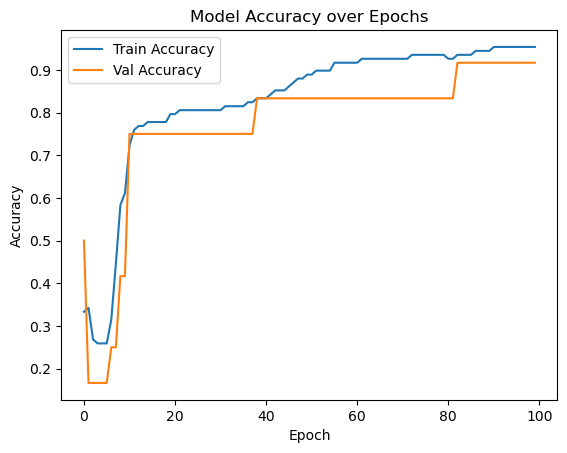

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()